# 计算一些质量参数，并且比较

In [104]:
import pandas as pd
import re
qualscore = pd.read_csv('./qualscore_0703.csv')
def spectrum_to_title(spectrum):
    # 去掉.dta
    spectrum = spectrum.replace('.dta', '')
    # 匹配主干和数字部分
    match = re.match(r'(.+?)_(\d+)\.(\d+)\.(\d+)\.(\d+)', spectrum)
    if not match:
        return None
    prefix, n1, n2, n3, n4 = match.groups()
    # 去掉补零
    n2, n3 = str(int(n2)), str(int(n3))
    # 拼接title格式
    title = f"{prefix}_{n1}.{n2}.{n3}.{n4}_SCANS{n3}"
    return title

# 应用到DataFrame
qualscore['mgf_title'] = qualscore['Spectrum'].apply(spectrum_to_title)

In [ ]:
import numpy as np
import pandas as pd
from pyteomics import mgf

mgf_path = "/rd1/user/lit/project/sORFs/src/C8_processed/CAD20250514licq_BSEP_DDA_60min_21pcw_1_C8_T_T_Slot2-3_1_7020_uncalibrated.mgf"

# ----------- 基本统计函数 -----------
def mean_intensity(peaks):
    intensities = [i for mz, i in peaks]
    return np.mean(intensities) if intensities else np.nan

def top20_mean_intensity(peaks):
    intensities = sorted([i for mz, i in peaks], reverse=True)
    top20 = intensities[:20] if len(intensities) >= 20 else intensities
    return np.mean(top20) if top20 else np.nan

def high_intensity_mean(peaks, n_sections=5, percentile=80):
    if not peaks:
        return np.nan
    peaks = sorted(peaks, key=lambda x: x[0])  # 按m/z排序
    mzs = [mz for mz, i in peaks]
    min_mz, max_mz = min(mzs), max(mzs)
    section_edges = np.linspace(min_mz, max_mz, n_sections + 1)
    high_intensity_peaks = []
    for i in range(n_sections):
        section_peaks = [p for p in peaks if section_edges[i] <= p[0] < section_edges[i+1]]
        if section_peaks:
            intensities = [p[1] for p in section_peaks]
            cutoff = np.percentile(intensities, percentile)
            high_intensity_peaks.extend([p for p in section_peaks if p[1] > cutoff])
    if high_intensity_peaks:
        return np.mean([p[1] for p in high_intensity_peaks])
    else:
        return np.nan

def normalize_peaks(peaks):
    if not peaks:
        return []
    max_int = max(i for mz, i in peaks)
    if max_int == 0:
        return [(mz, 0) for mz, i in peaks]
    return [(mz, i / max_int) for mz, i in peaks]

# ----------- 多种信噪比计算方法 -----------
def snr_topN_vs_median(peaks, top_n=5):
    intensities = [i for mz, i in peaks]
    if not intensities:
        return np.nan
    signal = np.mean(sorted(intensities, reverse=True)[:top_n])
    noise = np.median(intensities)
    return signal / noise if noise > 0 else np.nan

def snr_max_vs_median(peaks):
    intensities = [i for mz, i in peaks]
    if not intensities:
        return np.nan
    signal = max(intensities)
    noise = np.median(intensities)
    return signal / noise if noise > 0 else np.nan

def snr_max_vs_mean(peaks):
    intensities = [i for mz, i in peaks]
    if not intensities:
        return np.nan
    signal = max(intensities)
    noise = np.mean(intensities)
    return signal / noise if noise > 0 else np.nan

def snr_topN_vs_bottom_percent(peaks, top_n=5, bottom_percent=0.2):
    intensities = sorted([i for mz, i in peaks], reverse=True)
    if not intensities:
        return np.nan
    n_bottom = max(1, int(len(intensities) * bottom_percent))
    signal = np.mean(intensities[:top_n])
    noise = np.mean(intensities[-n_bottom:])
    return signal / noise if noise > 0 else np.nan

def snr_mean_vs_std(peaks):
    intensities = [i for mz, i in peaks]
    if not intensities:
        return np.nan
    mean = np.mean(intensities)
    std = np.std(intensities)
    return mean / std if std > 0 else np.nan

def snr_topN_vs_mean(peaks, top_n=5):
    intensities = sorted([i for mz, i in peaks], reverse=True)
    if not intensities:
        return np.nan
    signal = np.mean(intensities[:top_n])
    noise = np.mean(intensities)
    return signal / noise if noise > 0 else np.nan

# ----------- 主循环 -----------
results = []

for spectrum in mgf.read(mgf_path):
    peaks = list(zip(spectrum['m/z array'], spectrum['intensity array']))
    norm_peaks = normalize_peaks(peaks)
    title = spectrum.get('params', {}).get('title') or spectrum.get('title')

    # 原始强度
    mean_int = mean_intensity(peaks)
    top20_mean = top20_mean_intensity(peaks)
    high_int_mean = high_intensity_mean(peaks)
    snr1 = snr_topN_vs_median(peaks)
    snr2 = snr_max_vs_median(peaks)
    snr3 = snr_max_vs_mean(peaks)
    snr4 = snr_topN_vs_bottom_percent(peaks)
    snr5 = snr_mean_vs_std(peaks)
    snr6 = snr_topN_vs_mean(peaks)

    # 相对强度
    mean_int_rel = mean_intensity(norm_peaks)
    top20_mean_rel = top20_mean_intensity(norm_peaks)
    high_int_mean_rel = high_intensity_mean(norm_peaks)
    snr1_rel = snr_topN_vs_median(norm_peaks)
    snr2_rel = snr_max_vs_median(norm_peaks)
    snr3_rel = snr_max_vs_mean(norm_peaks)
    snr4_rel = snr_topN_vs_bottom_percent(norm_peaks)
    snr5_rel = snr_mean_vs_std(norm_peaks)
    snr6_rel = snr_topN_vs_mean(norm_peaks)

    results.append({
        'mgf_title': title,
        'total_peaks': len(peaks),

        'mean_intensity': mean_int,
        'mean_intensity_rel': mean_int_rel,

        'top20_mean_intensity': top20_mean,
        'top20_mean_intensity_rel': top20_mean_rel,

        'high_intensity_mean': high_int_mean,
        'high_intensity_mean_rel': high_int_mean_rel,

        'snr_topN_vs_median': snr1,
        'snr_topN_vs_median_rel': snr1_rel,

        'snr_max_vs_median': snr2,
        'snr_max_vs_median_rel': snr2_rel,

        'snr_max_vs_mean': snr3,
        'snr_max_vs_mean_rel': snr3_rel,

        'snr_topN_vs_bottom_percent': snr4,
        'snr_topN_vs_bottom_percent_rel': snr4_rel,

        'snr_mean_vs_std': snr5,
        'snr_mean_vs_std_rel': snr5_rel,

        'snr_topN_vs_mean': snr6,
        'snr_topN_vs_mean_rel': snr6_rel,
    })

df = pd.DataFrame(results)
print(df)
# df.to_csv('mgf_stats_all_metrics.csv', index=False)

In [70]:
# 如需保存
df.to_csv('mgf_stats.csv', index=False)

In [100]:
df.head()
# qualscore.head()

,mgf_title,total_peaks,mean_intensity,mean_intensity_rel,top20_mean_intensity,top20_mean_intensity_rel,high_intensity_mean,high_intensity_mean_rel,snr_topN_vs_median,snr_topN_vs_median_rel,snr_max_vs_median,snr_max_vs_median_rel,snr_max_vs_mean,snr_max_vs_mean_rel,snr_topN_vs_bottom_percent,snr_topN_vs_bottom_percent_rel,snr_mean_vs_std,snr_mean_vs_std_rel,snr_topN_vs_mean,snr_topN_vs_mean_rel
0,CAD20250514licq_BSEP_DDA_60min_21pcw_1_C8_T_T_Slot2-3_1_7020.1.1.2_SCANS1,205,51.424390,0.300727,122.45,0.716082,100.846154,0.589744,2.957692,2.957692,3.288462,3.288462,3.325270,3.325270,15.380000,15.380000,1.477044,1.477044,2.990799,2.990799
1,CAD20250514licq_BSEP_DDA_60min_21pcw_1_C8_T_T_Slot2-3_1_7020.2.2.2_SCANS2,264,54.625000,0.182692,150.45,0.503177,115.058824,0.384812,4.365385,4.365385,5.750000,5.750000,5.473684,5.473684,22.700000,22.700000,1.334023,1.334023,4.155606,4.155606
2,CAD20250514licq_BSEP_DDA_60min_21pcw_1_C8_T_T_Slot2-3_1_7020.3.3.1_SCANS3,67,408.417910,0.023034,1270.50,0.071654,1773.357143,0.100015,79.098305,79.098305,300.525424,300.525424,43.413865,43.413865,324.429947,324.429947,0.188142,0.188142,11.426531,11.426531
3,CAD20250514licq_BSEP_DDA_60min_21pcw_1_C8_T_T_Slot2-3_1_7020.4.4.1_SCANS4,97,346.865979,0.015440,1529.30,0.068072,1525.150000,0.067887,126.634783,126.634783,488.391304,488.391304,64.768531,64.768531,529.563636,529.563636,0.149448,0.149448,16.793806,16.793806
4,CAD20250514licq_BSEP_DDA_60min_21pcw_1_C8_T_T_Slot2-3_1_7020.5.5.1_SCANS5,40,822.875000,0.038288,1626.20,0.075665,3964.000000,0.184441,141.074157,141.074157,482.966292,482.966292,26.118183,26.118183,612.468293,612.468293,0.232241,0.232241,7.629105,7.629105


In [101]:
qualscore.Type.value_counts()

Type
Assigned      56926
Unassigned    51220
Name: count, dtype: int64

In [80]:
metrics = list(df.columns[1:])
titles = [col.replace('_', ' ').title() for col in metrics]

In [112]:
metrics

['total_peaks',
 'mean_intensity',
 'mean_intensity_rel',
 'top20_mean_intensity',
 'top20_mean_intensity_rel',
 'high_intensity_mean',
 'high_intensity_mean_rel',
 'snr_topN_vs_median',
 'snr_topN_vs_median_rel',
 'snr_max_vs_median',
 'snr_max_vs_median_rel',
 'snr_max_vs_mean',
 'snr_max_vs_mean_rel',
 'snr_topN_vs_bottom_percent',
 'snr_topN_vs_bottom_percent_rel',
 'snr_mean_vs_std',
 'snr_mean_vs_std_rel',
 'snr_topN_vs_mean',
 'snr_topN_vs_mean_rel']

In [105]:
merged = pd.merge(df, qualscore, on='mgf_title', how='inner')

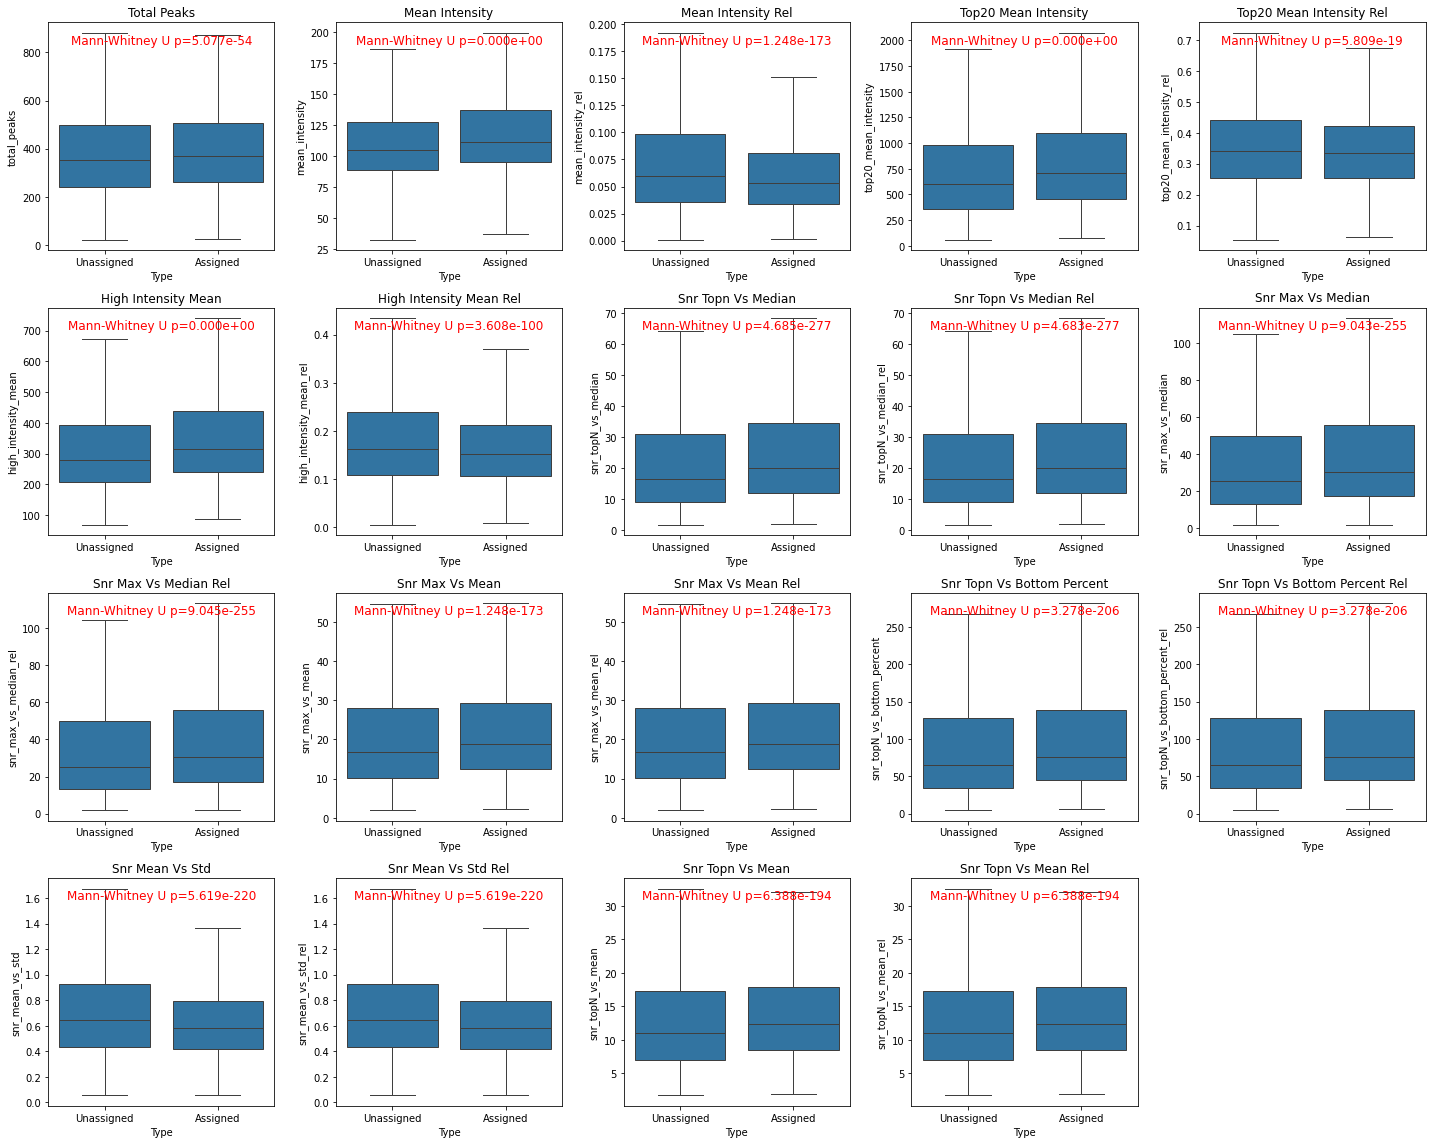

In [106]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wilcoxon, mannwhitneyu
import numpy as np

metrics = list(df.columns[1:])
titles = [col.replace('_', ' ').title() for col in metrics]

n_metrics = len(metrics)
ncols = 5
nrows = int(np.ceil(n_metrics / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 4*nrows))
axes = axes.flatten()  # 展平成一维

for i, (metric, title) in enumerate(zip(metrics, titles)):
    sns.boxplot(
        data=merged,
        x='Type',
        y=metric,
        showfliers=False,
        ax=axes[i]
    )
    axes[i].set_title(title)
    axes[i].set_xlabel('Type')
    axes[i].set_ylabel(metric)

    # 显著性检验
    group_values = [merged[merged['Type'] == t][metric].dropna() for t in merged['Type'].unique()]
    if len(group_values) == 2:
        # 检查是否为配对样本，否则用Mann-Whitney U
        if len(group_values[0]) == len(group_values[1]):
            stat, p = wilcoxon(group_values[0], group_values[1])
            test_name = 'Wilcoxon'
        else:
            stat, p = mannwhitneyu(group_values[0], group_values[1])
            test_name = 'Mann-Whitney U'
        axes[i].text(
            0.5, 0.95,
            f'{test_name} p={p:.3e}',
            ha='center', va='top', transform=axes[i].transAxes, fontsize=12, color='red'
        )
    else:
        axes[i].text(
            0.5, 0.95,
            'Group count != 2',
            ha='center', va='top', transform=axes[i].transAxes, fontsize=12, color='red'
        )

# 隐藏多余的子图
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

## Deprecated

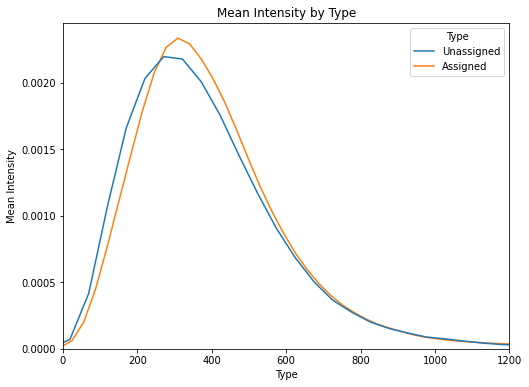

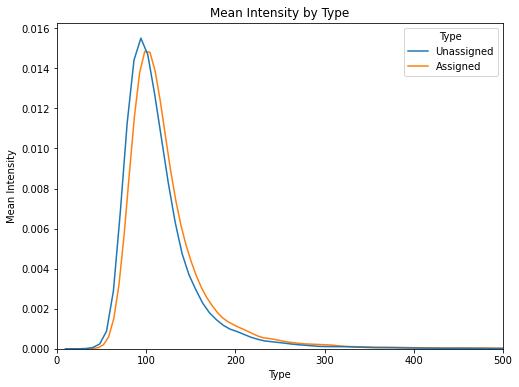

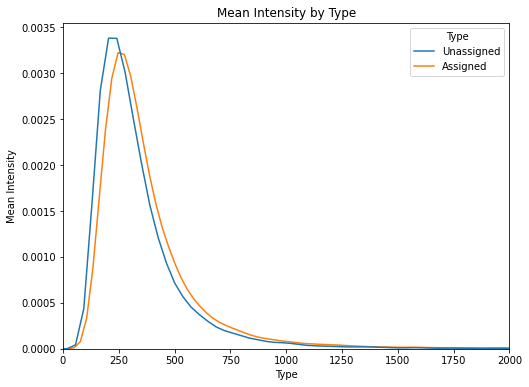

In [120]:
# 合并
merged = pd.merge(df, qualscore, on='mgf_title', how='inner')

import seaborn as sns

# plt.figure(figsize=(10, 6))
# merged.boxplot(column='mean_intensity', by='Type')
# plt.title('Mean Intensity by Type')
# plt.suptitle('')
# plt.xlabel('Type')
# plt.ylabel('Mean Intensity')
# plt.show()

# 绘制密度曲线
plt.figure(figsize=(8, 6))
sns.kdeplot(data=merged, x='total_peaks', hue='Type', common_norm=False)
plt.title('Mean Intensity by Type')
plt.xlabel('Type')
plt.ylabel('Mean Intensity')
plt.xlim(0, 1200)  # 设置x轴区间，根据你的数据实际范围调整
plt.show()

plt.figure(figsize=(8, 6))
sns.kdeplot(data=merged, x='mean_intensity', hue='Type', common_norm=False)
plt.title('Mean Intensity by Type')
plt.xlabel('Type')
plt.ylabel('Mean Intensity')
plt.xlim(0, 500)  # 设置x轴区间，根据你的数据实际范围调整
plt.show()

plt.figure(figsize=(8, 6))
sns.kdeplot(data=merged, x='high_intensity_mean', hue='Type', common_norm=False)
plt.title('Mean Intensity by Type')
plt.xlabel('Type')
plt.ylabel('Mean Intensity')
plt.xlim(0, 2000)  # 设置x轴区间，根据你的数据实际范围调整
plt.show()

In [110]:
# import matplotlib.pyplot as plt
# import seaborn as sns
# from scipy.stats import wilcoxon, mannwhitneyu

# fig, axes = plt.subplots(1, 3, figsize=(18, 6))
# metrics = ['mean_intensity', 'top20_mean_intensity', 'signal_to_noise']
# titles = ['Mean Intensity', 'Top20 Mean Intensity', 'Signal to Noise']

# for i, (metric, title) in enumerate(zip(metrics, titles)):
#     # 先画小提琴图
#     sns.violinplot(
#         data=merged,
#         x='Type',
#         y=metric,
#         inner=None,
#         ax=axes[i],
#         color='lightgray'
#     )
#     # 再叠加箱线图
#     sns.boxplot(
#         data=merged,
#         x='Type',
#         y=metric,
#         showfliers=False,
#         width=0.2,
#         ax=axes[i],
#         boxprops=dict(alpha=0.7)
#     )
#     axes[i].set_title(title)
#     axes[i].set_xlabel('Type')
#     axes[i].set_ylabel(metric)

#     # 显著性检验
#     group_values = [merged[merged['Type'] == t][metric].dropna() for t in merged['Type'].unique()]
#     if len(group_values) == 2:
#         if len(group_values[0]) == len(group_values[1]):
#             stat, p = wilcoxon(group_values[0], group_values[1])
#             test_name = 'Wilcoxon'
#         else:
#             stat, p = mannwhitneyu(group_values[0], group_values[1])
#             test_name = 'Mann-Whitney U'
#         axes[i].text(
#             0.5, 0.95,
#             f'{test_name} p={p:.3e}',
#             ha='center', va='top', transform=axes[i].transAxes, fontsize=12, color='red'
#         )
#     else:
#         axes[i].text(
#             0.5, 0.95,
#             'Group count != 2',
#             ha='center', va='top', transform=axes[i].transAxes, fontsize=12, color='red'
#         )

# plt.tight_layout()
# plt.show()

# 可视化qualscore前10和后10的20个谱图

In [24]:
import pandas as pd
qualscore = pd.read_csv('./qualscore_0704.csv')

In [25]:
import re

def spectrum_to_title(spectrum):
    # 去掉.dta
    spectrum = spectrum.replace('.dta', '')
    # 匹配主干和数字部分
    match = re.match(r'(.+?)_(\d+)\.(\d+)\.(\d+)\.(\d+)', spectrum)
    if not match:
        return None
    prefix, n1, n2, n3, n4 = match.groups()
    # 去掉补零
    n2, n3 = str(int(n2)), str(int(n3))
    # 拼接title格式
    title = f"{prefix}_{n1}.{n2}.{n3}.{n4}_SCANS{n3}"
    return title

# 应用到DataFrame
qualscore['mgf_title'] = qualscore['Spectrum'].apply(spectrum_to_title)

In [26]:
import pandas as pd
pd.set_option('display.max_colwidth', None)
print(qualscore.mgf_title.head())

0    CAD20250514licq_BSEP_DDA_60min_21pcw_1_C8_T_T_Slot2-3_1_7020.76.76.3_SCANS76
1    CAD20250514licq_BSEP_DDA_60min_21pcw_1_C8_T_T_Slot2-3_1_7020.79.79.4_SCANS79
2    CAD20250514licq_BSEP_DDA_60min_21pcw_1_C8_T_T_Slot2-3_1_7020.81.81.3_SCANS81
3    CAD20250514licq_BSEP_DDA_60min_21pcw_1_C8_T_T_Slot2-3_1_7020.82.82.3_SCANS82
4    CAD20250514licq_BSEP_DDA_60min_21pcw_1_C8_T_T_Slot2-3_1_7020.83.83.4_SCANS83
Name: mgf_title, dtype: object


In [32]:
from pyteomics import mgf

input_mgf = mgf_path      # 原始mgf文件名
output_mgf = 'test_top10.mgf'  # 输出的mgf文件名

# 读取前10个谱图
spectra = []
with mgf.read(input_mgf) as reader:
    for i, spec in enumerate(reader):
        if i >= 10:
            break
        spectra.append(spec)

# 正确写法：直接调用mgf.write
mgf.write(spectra, output_mgf)

print(f"已将前10个谱图写入 {output_mgf}")

已将前10个谱图写入 test_top10.mgf


In [35]:
import pandas as pd
import matplotlib.pyplot as plt
from pyteomics import mgf

# 2. 读取mgf，建立title到谱图的映射
mgf_dict = {}
with mgf.read(mgf_path) as spectra:
    for spec in spectra:
        title = spec.get('params', {}).get('title') or spec.get('title')
        if title:
            mgf_dict[title] = spec

In [34]:
mgf_dict

{'CAD20250514licq_BSEP_DDA_60min_21pcw_1_C8_T_T_Slot2-3_1_7020.1.1.2_SCANS1': {'params': {'title': 'CAD20250514licq_BSEP_DDA_60min_21pcw_1_C8_T_T_Slot2-3_1_7020.1.1.2_SCANS1',
   'pepmass': (566.335152365549, None),
   'rtinseconds': 2.7954855 second,
   'charge': [2],
   'scans': '1',
   '1/k0': '0.7971748'},
  'm/z array': array([ 126.32317,  139.65013,  139.88448,  180.85214,  203.58907,
          221.13023,  229.92047,  251.61766,  284.08942,  298.5206 ,
          325.5995 ,  331.34717,  332.9786 ,  333.71405,  334.90067,
          335.05865,  349.51328,  355.42517,  368.8699 ,  389.89938,
          389.9183 ,  401.92474,  401.94397,  410.95428,  413.8856 ,
          416.84036,  417.25168,  421.58594,  429.06915,  434.8731 ,
          439.7736 ,  439.83728,  443.83902,  455.8403 ,  460.7577 ,
          461.90097,  465.89465,  465.97745,  470.82767,  471.77505,
          472.772  ,  474.96417,  475.5252 ,  480.38272,  480.996  ,
          496.81198,  498.81635,  504.74988,  508.7904

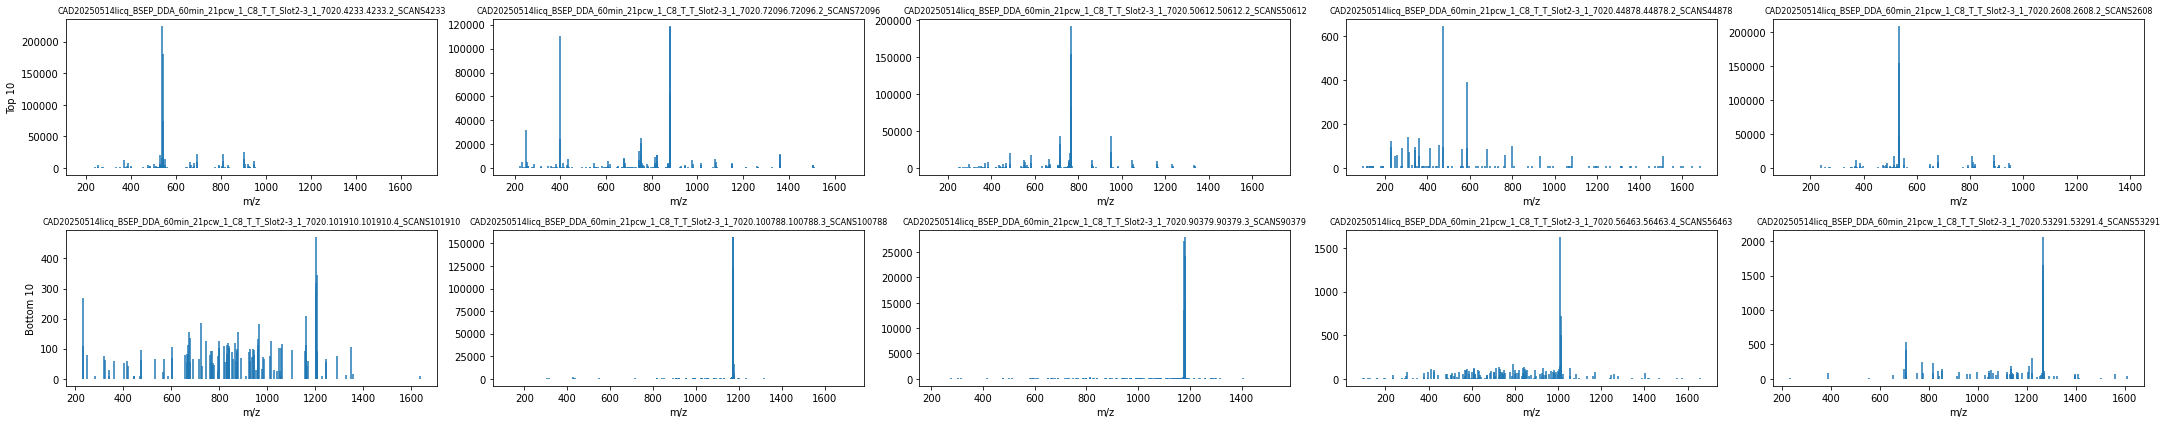

In [41]:
# 3. 排序并选出前10和后10
qualscore_sorted = qualscore.sort_values('Qualscore', ascending=False)
top10 = qualscore_sorted.head(5)['mgf_title'].tolist()
bottom10 = qualscore_sorted.tail(5)['mgf_title'].tolist()

# 4. 提取谱图
top10_spectra = [mgf_dict[title] for title in top10 if title in mgf_dict]
bottom10_spectra = [mgf_dict[title] for title in bottom10 if title in mgf_dict]

# 5. 可视化
fig, axes = plt.subplots(2, 5, figsize=(30, 6), sharey=False)
for i, (ax, title, spec) in enumerate(zip(axes[0], top10, top10_spectra)):
    mz = spec['m/z array']
    intensity = spec['intensity array']
    ax.vlines(mz, [0], intensity)
    ax.set_title(title, fontsize=8)
    ax.set_xlabel('m/z')
    if i == 0:
        ax.set_ylabel('Top 10')
for i, (ax, title, spec) in enumerate(zip(axes[1], bottom10, bottom10_spectra)):
    mz = spec['m/z array']
    intensity = spec['intensity array']
    ax.vlines(mz, [0], intensity)
    ax.set_title(title, fontsize=8)
    ax.set_xlabel('m/z')
    if i == 0:
        ax.set_ylabel('Bottom 10')
plt.tight_layout()
plt.show()

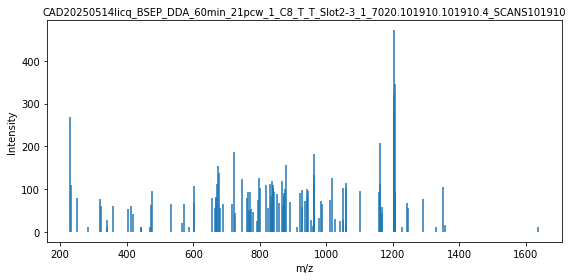

In [40]:
from pyteomics import mgf
import matplotlib.pyplot as plt

mgf_file = mgf_path
target_title = 'CAD20250514licq_BSEP_DDA_60min_21pcw_1_C8_T_T_Slot2-3_1_7020.101910.101910.4_SCANS101910'

# 遍历mgf文件，找到目标title
spectrum = None
with mgf.read(mgf_file) as reader:
    for spec in reader:
        title = spec.get('params', {}).get('title') or spec.get('title')
        if title == target_title:
            spectrum = spec
            break

if spectrum is not None:
    mz = spectrum['m/z array']
    intensity = spectrum['intensity array']
    plt.figure(figsize=(8, 4))
    plt.vlines(mz, [0], intensity)
    plt.title(target_title, fontsize=10)
    plt.xlabel('m/z')
    plt.ylabel('Intensity')
    plt.tight_layout()
    plt.show()
else:
    print(f"未找到title为 {target_title} 的谱图")

In [121]:
qualscore_sorted.head(5)

,Spectrum,Probability,Qualscore,scan,Type,mgf_title
3589,CAD20250514licq_BSEP_DDA_60min_21pcw_1_C8_T_T_Slot2-3_1_7020.4233.4233.2.dta,1.0,3.260636,4233,Assigned,CAD20250514licq_BSEP_DDA_60min_21pcw_1_C8_T_T_Slot2-3_1_7020.4233.4233.2_SCANS4233
66337,CAD20250514licq_BSEP_DDA_60min_21pcw_1_C8_T_T_Slot2-3_1_7020.72096.72096.2.dta,1.0,3.233253,72096,Assigned,CAD20250514licq_BSEP_DDA_60min_21pcw_1_C8_T_T_Slot2-3_1_7020.72096.72096.2_SCANS72096
46237,CAD20250514licq_BSEP_DDA_60min_21pcw_1_C8_T_T_Slot2-3_1_7020.50612.50612.2.dta,1.0,2.980656,50612,Assigned,CAD20250514licq_BSEP_DDA_60min_21pcw_1_C8_T_T_Slot2-3_1_7020.50612.50612.2_SCANS50612
40919,CAD20250514licq_BSEP_DDA_60min_21pcw_1_C8_T_T_Slot2-3_1_7020.44878.44878.2.dta,1.0,2.804746,44878,Assigned,CAD20250514licq_BSEP_DDA_60min_21pcw_1_C8_T_T_Slot2-3_1_7020.44878.44878.2_SCANS44878
2121,CAD20250514licq_BSEP_DDA_60min_21pcw_1_C8_T_T_Slot2-3_1_7020.2608.2608.2.dta,1.0,2.725236,2608,Assigned,CAD20250514licq_BSEP_DDA_60min_21pcw_1_C8_T_T_Slot2-3_1_7020.2608.2608.2_SCANS2608


In [122]:
qualscore_sorted.tail(5)

,Spectrum,Probability,Qualscore,scan,Type,mgf_title
93939,CAD20250514licq_BSEP_DDA_60min_21pcw_1_C8_T_T_Slot2-3_1_7020.101910.101910.4.dta,0.0,-2.858934,101910,Unassigned,CAD20250514licq_BSEP_DDA_60min_21pcw_1_C8_T_T_Slot2-3_1_7020.101910.101910.4_SCANS101910
92911,CAD20250514licq_BSEP_DDA_60min_21pcw_1_C8_T_T_Slot2-3_1_7020.100788.100788.3.dta,1.0,-3.002448,100788,Assigned,CAD20250514licq_BSEP_DDA_60min_21pcw_1_C8_T_T_Slot2-3_1_7020.100788.100788.3_SCANS100788
83472,CAD20250514licq_BSEP_DDA_60min_21pcw_1_C8_T_T_Slot2-3_1_7020.90379.90379.3.dta,1.0,-3.242499,90379,Assigned,CAD20250514licq_BSEP_DDA_60min_21pcw_1_C8_T_T_Slot2-3_1_7020.90379.90379.3_SCANS90379
51738,CAD20250514licq_BSEP_DDA_60min_21pcw_1_C8_T_T_Slot2-3_1_7020.56463.56463.4.dta,0.0,-3.275579,56463,Unassigned,CAD20250514licq_BSEP_DDA_60min_21pcw_1_C8_T_T_Slot2-3_1_7020.56463.56463.4_SCANS56463
48737,CAD20250514licq_BSEP_DDA_60min_21pcw_1_C8_T_T_Slot2-3_1_7020.53291.53291.4.dta,0.0,-3.293063,53291,Unassigned,CAD20250514licq_BSEP_DDA_60min_21pcw_1_C8_T_T_Slot2-3_1_7020.53291.53291.4_SCANS53291


In [95]:
df.head()

,mgf_title,total_peaks,mean_intensity,mean_intensity_rel,top20_mean_intensity,top20_mean_intensity_rel,high_intensity_mean,high_intensity_mean_rel,snr_topN_vs_median,snr_topN_vs_median_rel,snr_max_vs_median,snr_max_vs_median_rel,snr_max_vs_mean,snr_max_vs_mean_rel,snr_topN_vs_bottom_percent,snr_topN_vs_bottom_percent_rel,snr_mean_vs_std,snr_mean_vs_std_rel,snr_topN_vs_mean,snr_topN_vs_mean_rel
0,CAD20250514licq_BSEP_DDA_60min_21pcw_1_C8_T_T_Slot2-3_1_7020.1.1.2_SCANS1,205,51.424390,0.300727,122.45,0.716082,100.846154,0.589744,2.957692,2.957692,3.288462,3.288462,3.325270,3.325270,15.380000,15.380000,1.477044,1.477044,2.990799,2.990799
1,CAD20250514licq_BSEP_DDA_60min_21pcw_1_C8_T_T_Slot2-3_1_7020.2.2.2_SCANS2,264,54.625000,0.182692,150.45,0.503177,115.058824,0.384812,4.365385,4.365385,5.750000,5.750000,5.473684,5.473684,22.700000,22.700000,1.334023,1.334023,4.155606,4.155606
2,CAD20250514licq_BSEP_DDA_60min_21pcw_1_C8_T_T_Slot2-3_1_7020.3.3.1_SCANS3,67,408.417910,0.023034,1270.50,0.071654,1773.357143,0.100015,79.098305,79.098305,300.525424,300.525424,43.413865,43.413865,324.429947,324.429947,0.188142,0.188142,11.426531,11.426531
3,CAD20250514licq_BSEP_DDA_60min_21pcw_1_C8_T_T_Slot2-3_1_7020.4.4.1_SCANS4,97,346.865979,0.015440,1529.30,0.068072,1525.150000,0.067887,126.634783,126.634783,488.391304,488.391304,64.768531,64.768531,529.563636,529.563636,0.149448,0.149448,16.793806,16.793806
4,CAD20250514licq_BSEP_DDA_60min_21pcw_1_C8_T_T_Slot2-3_1_7020.5.5.1_SCANS5,40,822.875000,0.038288,1626.20,0.075665,3964.000000,0.184441,141.074157,141.074157,482.966292,482.966292,26.118183,26.118183,612.468293,612.468293,0.232241,0.232241,7.629105,7.629105


In [96]:
df[df['mgf_title'] == "CAD20250514licq_BSEP_DDA_60min_21pcw_1_C8_T_T_Slot2-3_1_7020.100788.100788.3_SCANS100788"]

,mgf_title,total_peaks,mean_intensity,mean_intensity_rel,top20_mean_intensity,top20_mean_intensity_rel,high_intensity_mean,high_intensity_mean_rel,snr_topN_vs_median,snr_topN_vs_median_rel,snr_max_vs_median,snr_max_vs_median_rel,snr_max_vs_mean,snr_max_vs_mean_rel,snr_topN_vs_bottom_percent,snr_topN_vs_bottom_percent_rel,snr_mean_vs_std,snr_mean_vs_std_rel,snr_topN_vs_mean,snr_topN_vs_mean_rel
98983,CAD20250514licq_BSEP_DDA_60min_21pcw_1_C8_T_T_Slot2-3_1_7020.100788.100788.3_SCANS100788,884,880.734163,0.005606,34273.25,0.218151,4111.223464,0.026168,1758.217391,1758.217391,2276.927536,2276.927536,178.382998,178.382998,7365.22663,7365.22663,0.092637,0.092637,137.74531,137.74531


In [97]:
df[df['mgf_title'] == "CAD20250514licq_BSEP_DDA_60min_21pcw_1_C8_T_T_Slot2-3_1_7020.72096.72096.2_SCANS72096"]

,mgf_title,total_peaks,mean_intensity,mean_intensity_rel,top20_mean_intensity,top20_mean_intensity_rel,high_intensity_mean,high_intensity_mean_rel,snr_topN_vs_median,snr_topN_vs_median_rel,snr_max_vs_median,snr_max_vs_median_rel,snr_max_vs_mean,snr_max_vs_mean_rel,snr_topN_vs_bottom_percent,snr_topN_vs_bottom_percent_rel,snr_mean_vs_std,snr_mean_vs_std_rel,snr_topN_vs_mean,snr_topN_vs_mean_rel
70736,CAD20250514licq_BSEP_DDA_60min_21pcw_1_C8_T_T_Slot2-3_1_7020.72096.72096.2_SCANS72096,1725,600.613333,0.005068,32322.95,0.272747,2768.236152,0.023359,1319.023881,1319.023881,1768.791045,1768.791045,197.313302,197.313302,5448.39832,5448.39832,0.112978,0.112978,147.14059,147.14059
